In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

print("Libraries imported successfully!")
print("Project: Autocomplete and Autocorrect Data Analytics")


Libraries imported successfully!
Project: Autocomplete and Autocorrect Data Analytics


In [2]:
sentences = [
    "data analytics helps businesses make better decisions",
    "data science uses statistics and machine learning",
    "machine learning improves data analytics",
    "artificial intelligence helps analyse large datasets",
    "data analytics includes data cleaning and visualization",
    "machine learning can support predictive analytics",
    "autocomplete suggests words while typing",
    "autocorrect helps correct spelling mistakes",
    "data science and analytics are growing fields",
    "artificial intelligence improves language processing"
]

text_data = " ".join(sentences).lower()

print("Sample text prepared successfully!")
print("Number of sentences:", len(sentences))
print("\nSample sentences:")
for sentence in sentences:
    print("-", sentence)




Sample text prepared successfully!
Number of sentences: 10

Sample sentences:
- data analytics helps businesses make better decisions
- data science uses statistics and machine learning
- machine learning improves data analytics
- artificial intelligence helps analyse large datasets
- data analytics includes data cleaning and visualization
- machine learning can support predictive analytics
- autocomplete suggests words while typing
- autocorrect helps correct spelling mistakes
- data science and analytics are growing fields
- artificial intelligence improves language processing


Total words: 60
Unique words: 39

Top 10 most frequent words:
data : 6
analytics : 5
helps : 3
and : 3
machine : 3
learning : 3
science : 2
improves : 2
artificial : 2
intelligence : 2


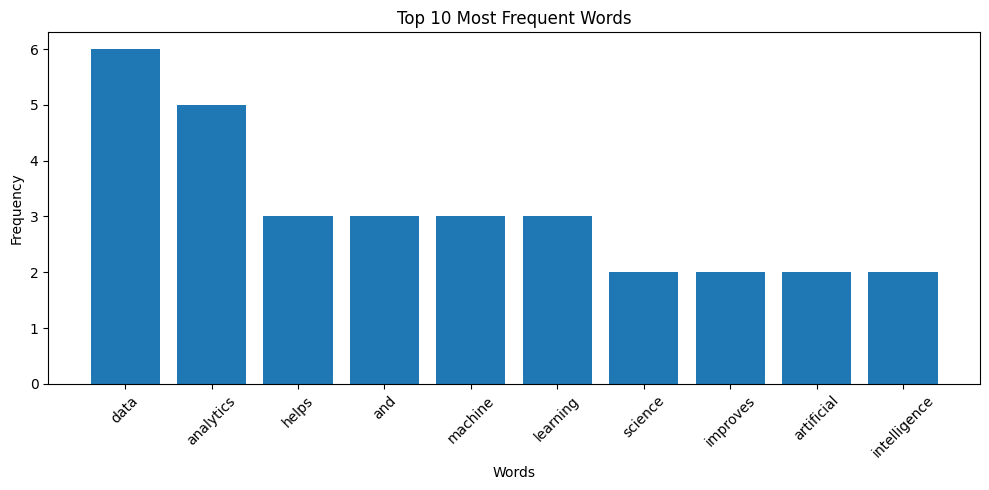

Text cleaning and word analysis completed!


In [3]:
# Clean and tokenize the text
clean_text = re.sub(r"[^a-z\s]", "", text_data.lower())
words = clean_text.split()

# Count word frequencies
word_counts = Counter(words)

print("Total words:", len(words))
print("Unique words:", len(word_counts))

print("\nTop 10 most frequent words:")
for word, count in word_counts.most_common(10):
    print(word, ":", count)

# Plot the top 10 words
top_words = word_counts.most_common(10)
word_labels = [item[0] for item in top_words]
word_values = [item[1] for item in top_words]

plt.figure(figsize=(10, 5))
plt.bar(word_labels, word_values)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Text cleaning and word analysis completed!")




In [4]:
# Build autocomplete using words from our text
def autocomplete(prefix, max_suggestions=5):
    prefix = prefix.lower().strip()

    matches = [
        word for word in word_counts
        if word.startswith(prefix)
    ]

    # Show most frequent matching words first
    matches.sort(
        key=lambda word: word_counts[word],
        reverse=True
    )

    return matches[:max_suggestions]


# Test autocomplete
test_prefixes = ["anal", "data", "mach", "art", "auto"]

for prefix in test_prefixes:
    print(f"\nSuggestions for '{prefix}':")
    print(autocomplete(prefix))

print("\nAutocomplete feature completed!")





Suggestions for 'anal':
['analytics', 'analyse']

Suggestions for 'data':
['data', 'datasets']

Suggestions for 'mach':
['machine']

Suggestions for 'art':
['artificial']

Suggestions for 'auto':
['autocomplete', 'autocorrect']

Autocomplete feature completed!


In [5]:
from difflib import get_close_matches

# Create a vocabulary from the cleaned text
vocabulary = set(word_counts.keys())

def autocorrect(word, max_suggestions=3):
    word = word.lower().strip()

    # Keep the word if it is already in the vocabulary
    if word in vocabulary:
        return word

    suggestions = get_close_matches(
        word,
        vocabulary,
        n=max_suggestions,
        cutoff=0.6
    )

    if suggestions:
        return suggestions

    return "No close match found"


# Test autocorrect
test_words = ["analytcs", "machne", "artifical", "vizualization", "busines"]

for word in test_words:
    print(f"{word} -> {autocorrect(word)}")

print("\nAutocorrect feature completed!")




analytcs -> ['analytics', 'analyse']
machne -> ['machine', 'make']
artifical -> ['artificial']
vizualization -> ['visualization']
busines -> ['businesses', 'uses']

Autocorrect feature completed!


In [6]:
# Test both features together
test_cases = [
    ("Autocomplete", "anal"),
    ("Autocomplete", "mach"),
    ("Autocomplete", "auto"),
    ("Autocorrect", "analytcs"),
    ("Autocorrect", "machne"),
    ("Autocorrect", "artifical")
]

test_results = []

for feature, word in test_cases:
    if feature == "Autocomplete":
        result = autocomplete(word)
    else:
        result = autocorrect(word)

    test_results.append({
        "Feature": feature,
        "Input": word,
        "Output": str(result)
    })

results_df = pd.DataFrame(test_results)
display(results_df)

print("Combined feature testing completed!")




,Feature,Input,Output
0,Autocomplete,anal,"['analytics', 'analyse']"
1,Autocomplete,mach,['machine']
2,Autocomplete,auto,"['autocomplete', 'autocorrect']"
3,Autocorrect,analytcs,"['analytics', 'analyse']"
4,Autocorrect,machne,"['machine', 'make']"
5,Autocorrect,artifical,['artificial']


Combined feature testing completed!


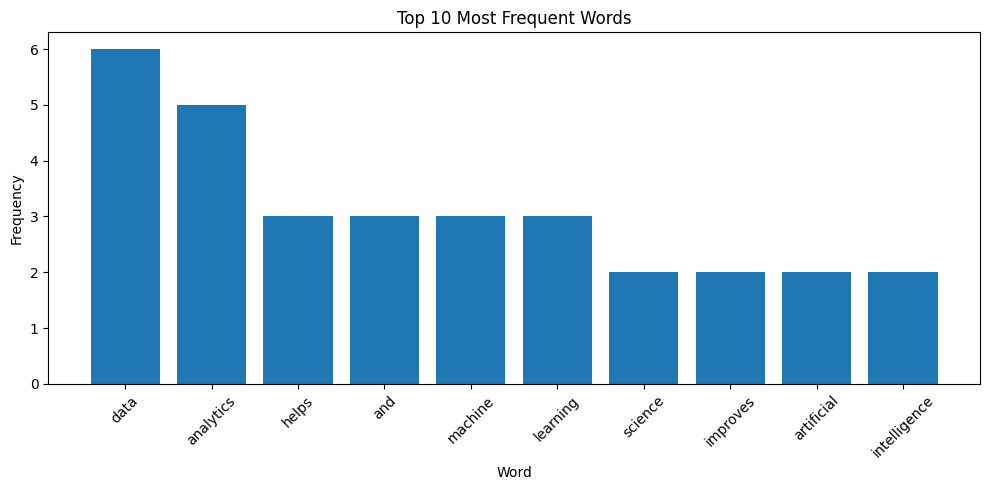

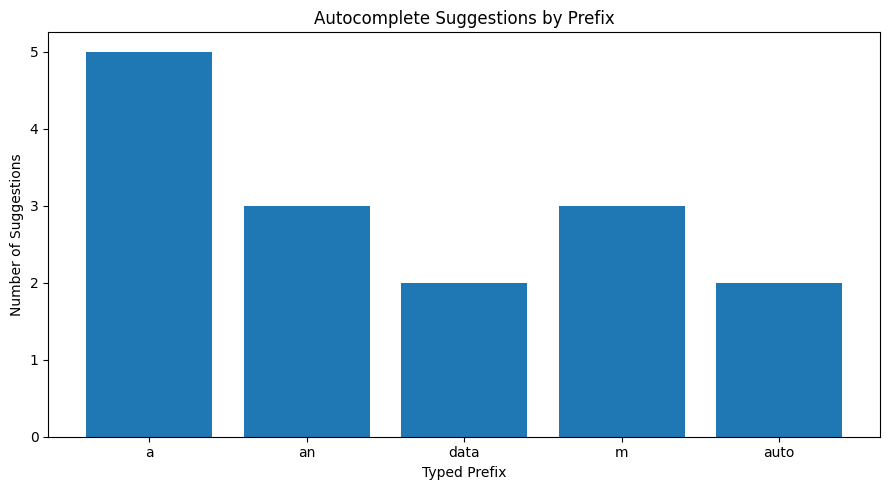

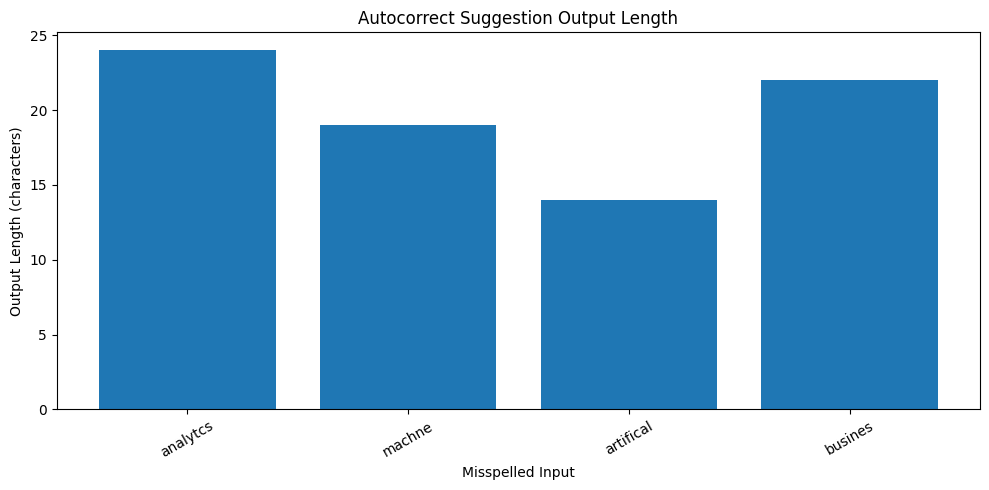

Visualizations completed!


In [7]:
# Graph 1: Top 10 most frequent words
top_words = word_counts.most_common(10)
labels = [item[0] for item in top_words]
values = [item[1] for item in top_words]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph 2: Number of autocomplete suggestions
prefixes = ["a", "an", "data", "m", "auto"]
suggestion_counts = [len(autocomplete(p)) for p in prefixes]

plt.figure(figsize=(9, 5))
plt.bar(prefixes, suggestion_counts)
plt.title("Autocomplete Suggestions by Prefix")
plt.xlabel("Typed Prefix")
plt.ylabel("Number of Suggestions")
plt.tight_layout()
plt.show()

# Graph 3: Autocorrect examples
test_words = ["analytcs", "machne", "artifical", "busines"]
corrections = [str(autocorrect(w)) for w in test_words]

plt.figure(figsize=(10, 5))
plt.bar(test_words, [len(c) for c in corrections])
plt.title("Autocorrect Suggestion Output Length")
plt.xlabel("Misspelled Input")
plt.ylabel("Output Length (characters)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Visualizations completed!")




In [8]:
print("=" * 55)
print("AUTOCOMPLETE AND AUTOCORRECT - PROJECT CONCLUSION")
print("=" * 55)

print("\n1. Text Dataset")
print("Total sentences:", len(sentences))
print("Total words:", len(words))
print("Unique words:", len(word_counts))

print("\n2. Most Frequent Words")
for word, count in word_counts.most_common(5):
    print(word, ":", count)

print("\n3. Autocomplete Test")
print("Suggestions for 'data':", autocomplete("data"))

print("\n4. Autocorrect Test")
for word in ["analytcs", "machne", "artifical"]:
    print(word, "->", autocorrect(word))

print("\nConclusion:")
print("This project analyses text data using Python.")
print("Word frequency analysis identifies commonly used words.")
print("Autocomplete suggests words based on a typed prefix.")
print("Autocorrect suggests similar words for possible spelling mistakes.")
print("The project demonstrates basic techniques used in text processing.")

print("\nProject completed!")




AUTOCOMPLETE AND AUTOCORRECT - PROJECT CONCLUSION

1. Text Dataset
Total sentences: 10
Total words: 60
Unique words: 39

2. Most Frequent Words
data : 6
analytics : 5
helps : 3
and : 3
machine : 3

3. Autocomplete Test
Suggestions for 'data': ['data', 'datasets']

4. Autocorrect Test
analytcs -> ['analytics', 'analyse']
machne -> ['machine', 'make']
artifical -> ['artificial']

Conclusion:
This project analyses text data using Python.
Word frequency analysis identifies commonly used words.
Autocomplete suggests words based on a typed prefix.
Autocorrect suggests similar words for possible spelling mistakes.
The project demonstrates basic techniques used in text processing.

Project completed!
